## TATA CLIQ SALES ANALYSIS

In [1]:
pip install panda

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## importing liabraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### importing data

In [73]:
customer=pd.read_csv("C:/Users/tannu/OneDrive/Desktop/DATAs/messy_customers.csv")
order_details=pd.read_csv("C:/Users/tannu/OneDrive/Desktop/DATAs/messy_order_items.csv")
order=pd.read_csv("C:/Users/tannu/OneDrive/Desktop/DATAs/messy_orders.csv")
product=pd.read_csv("C:/Users/tannu/OneDrive/Desktop/DATAs/messy_products.csv",encoding="latin1")

#data cleaning

In [74]:
customer

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


In [75]:
customer[customer.duplicated()]

,customer_id,customer_name,city,signup_date
500,C0309,Customer_309,Kolkata,2025-05-09
501,C0014,Customer_14,delhi,2024-08-18
502,C0415,Customer_415,Kolkata,2025-04-05
503,C0033,Customer_33,mumbai,2024-04-30
504,C0461,Customer_461,Chennai,2024-06-02
505,C0156,Customer_156,Pune,2024-08-07
506,C0250,Customer_250,Mumbai,2024-12-31
507,C0218,Customer_218,delhi,2025-02-02
508,C0222,Customer_222,Hyderabad,2024-05-20
509,C0294,Customer_294,Hyderabad,2023-09-12


In [76]:
customer.drop_duplicates(inplace=True)

In [77]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    500 non-null    str  
 1   customer_name  472 non-null    str  
 2   city           460 non-null    str  
 3   signup_date    500 non-null    str  
dtypes: str(4)
memory usage: 15.8 KB


In [78]:
customer.isnull().sum()

customer_id       0
customer_name    28
city             40
signup_date       0
dtype: int64

In [79]:
customer[['customer_name','city']]=customer[['customer_name','city']].fillna("unknown")

In [80]:
customer["signup_date"]=pd.to_datetime(customer["signup_date"])

In [81]:
customer['city'].value_counts()

city
delhi        51
Hyderabad    51
Pune         48
Mumbai       48
DELHI        43
Bangalore    41
Kolkata      41
unknown      40
mumbai       38
Delhi        37
Chennai      34
Bengaluru    28
Name: count, dtype: int64

In [82]:
customer['city']=customer['city'].str.capitalize()

In [83]:
customer['city']=customer['city'].replace({'Bengaluru':'Bangalore'})

In [84]:
customer

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,Delhi,2024-02-09
1,C0002,Customer_2,Delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,unknown,Bangalore,2024-03-04
...,...,...,...,...
495,C0496,Customer_496,Delhi,2023-01-01
496,C0497,unknown,Pune,2023-01-26
497,C0498,Customer_498,Mumbai,2023-06-13
498,C0499,Customer_499,Delhi,2023-01-13


In [85]:
order

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [86]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1240 non-null   str  
 1   customer_id     1240 non-null   str  
 2   order_date      1240 non-null   str  
 3   payment_method  1095 non-null   str  
dtypes: str(4)
memory usage: 38.9 KB


In [87]:
order.isnull().sum()

order_id            0
customer_id         0
order_date          0
payment_method    145
dtype: int64

In [88]:
order.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1235     True
1236     True
1237     True
1238     True
1239     True
Length: 1240, dtype: bool

In [89]:
order.drop_duplicates(inplace=True)

In [90]:
order["order_date"]=pd.to_datetime(order["order_date"],format="mixed")

In [91]:
order['payment_method']=order['payment_method'].str.capitalize()

In [92]:
order['payment_method']=order['payment_method'].replace({'Cash':'Cash on delivery','Cash on Delivery':"Cash on delivery"})

In [93]:
order['payment_method']=order['payment_method'].fillna("unknown")

In [94]:
order

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,2024-09-05,Cash on delivery
1,O00002,C0410,2024-02-01,Upi
2,O00003,C0429,2025-04-13,Cash on delivery
3,O00004,C0272,2024-02-25,Debit card
4,O00005,C0411,2025-04-26,Credit card
...,...,...,...,...
1195,O01196,C0392,2024-09-14,unknown
1196,O01197,C0260,2024-04-09,unknown
1197,O01198,C0459,2024-05-29,unknown
1198,O01199,C0130,2024-03-13,unknown


#O R D E R  TABLE COMPLETED

In [95]:
order_details

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [96]:
order_details.isnull().sum()

order_item_id       0
order_id            0
product_id          0
quantity          318
unit_price       1011
dtype: int64

In [97]:
order_details.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2045     True
2046     True
2047     True
2048     True
2049     True
Length: 2050, dtype: bool

In [98]:
order_details.drop_duplicates(inplace=True)

In [99]:
order_details['unit_price']=order_details['unit_price'].fillna(round(order_details['unit_price'].mean()))

In [100]:
zero_index=order_details[order_details['quantity']==0].index

In [101]:
order_details.drop(index=zero_index,inplace=True)

In [102]:
order_details['quantity']=order_details['quantity'].fillna(order_details['quantity'].round().mean())

In [103]:
order_details.info()

<class 'pandas.DataFrame'>
Index: 1672 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  1672 non-null   int64  
 1   order_id       1672 non-null   str    
 2   product_id     1672 non-null   str    
 3   quantity       1672 non-null   float64
 4   unit_price     1672 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 78.4 KB


In [104]:
order_details['quantity'].astype(int)

0       2
1       1
2       2
3       2
4       2
       ..
1994    3
1995    4
1996    4
1998    3
1999    2
Name: quantity, Length: 1672, dtype: int64

In [105]:
order_details

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.000000,44852.0
1,2,O00857,P010,1.000000,44852.0
2,3,O00589,P007,2.000000,77415.0
3,4,O00112,P045,2.000000,49066.0
4,5,O00322,P036,2.000000,58380.0
...,...,...,...,...,...
1994,1995,O00364,P005,3.000000,44852.0
1995,1996,O00944,P007,4.000000,64106.0
1996,1997,O00629,P017,4.000000,44852.0
1998,1999,O01083,P043,3.000000,18251.0


#O R D E R  D E T A I L   TABLE COMPLETED

In [106]:
product

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


In [107]:
product[product.duplicated()]

,product_id,product_name,category,base_price
80,P076,Wireless Mouse,Accessory,15249.0
81,P062,Dell Inspiron,Tablet,NaN
82,P072,Dell Inspiron,Tablet,NaN
83,P017,Keyboard,Smartphone,NaN
84,P020,Dell Inspiron,Smartphone,NaN
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN
89,P033,Wireless Mouse,laptop,47453.0


In [108]:
product.drop_duplicates(inplace=True)

In [109]:
product["category"].value_counts()

category
smart phone    15
Tablet         14
laptop         12
Accessories    10
Accessory      10
Smartphone      9
tablet          5
Laptop          5
Name: count, dtype: int64

In [110]:
product["category"]=product["category"].str.capitalize()

In [111]:
product["category"]=product["category"].replace({"Accessory":"Accessories","Smart phone":"Smartphone"})

In [112]:
product.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

In [113]:
mean=product.groupby('category')["base_price"].mean().round()

In [114]:
product[product['category']=='Laptop']=product[product['category']=='Laptop'].fillna(mean['Laptop'])
product[product['category']=='Smartphone']=product[product['category']=='Smartphone'].fillna(mean['Smartphone'])
product[product['category']=='Accessories']=product[product['category']=='Accessories'].fillna(mean['Accessories'])
product[product['category']=='Tablet']=product[product['category']=='Tablet'].fillna(mean['Tablet'])

In [115]:
product

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,44411.0
3,P004,Lenovo Tab,Tablet,40848.0
4,P005,OnePlus,Tablet,40848.0
...,...,...,...,...
75,P076,Wireless Mouse,Accessories,15249.0
76,P077,Wireless Mouse,Smartphone,50189.0
77,P078,USB Hub,Accessories,70378.0
78,P079,OnePlus,Tablet,40848.0


In [116]:
product.isnull().sum()

product_id      0
product_name    0
category        0
base_price      0
dtype: int64

In [117]:
index=product.set_index('product_id')['base_price']

In [118]:
mapping_value=order_details['product_id'].map(index)

In [119]:
order_details['unit_price'].fillna(mapping_value)

0       44852.0
1       44852.0
2       77415.0
3       49066.0
4       58380.0
         ...   
1994    44852.0
1995    64106.0
1996    44852.0
1998    18251.0
1999    33991.0
Name: unit_price, Length: 1672, dtype: float64

#P R O D U C T  TABLE COMPLETED

# D A T A   TRANSFORMING

In [120]:
customer["day_in_month"]=customer["signup_date"].dt.days_in_month ### 

In [121]:
customer["month"]=customer["signup_date"].dt.month_name()

In [122]:
customer["year"]=customer['signup_date'].dt.year

In [123]:
order["month"]=order["order_date"].dt.month_name()

In [124]:
order["year"]=order["order_date"].dt.year

In [125]:
order["day_of_month"]=order["order_date"].dt.days_in_month

In [126]:
order["quarter"] = order["order_date"].dt.quarter

In [127]:
order_details['revenue']=order_details['quantity'] * order_details['unit_price']

In [128]:
full_data = pd.merge(order,customer,on='customer_id').merge(order_details,on='order_id',how='left').merge(product,on='product_id',how='left')

## INSIGHTS

-- Total Revenue Generated till date

In [129]:
total_revenue=order_details['revenue'].sum().round()
print("Total revenue is",int(total_revenue/10000000),"cr")

Total revenue is 18 cr


-- Total Orders shipped till date

In [130]:
total_order=order_details['quantity'].sum().round()
print("Total order is",total_order)

Total order is 4149.0


-- Total Customers

In [131]:
total_customer=customer['customer_id'].nunique()
print("Total no. of customers are",total_customer)

Total no. of customers are 500


-- Average order value

In [132]:
order_value = order_details.groupby("order_id")["revenue"].mean()

print("Average Order Value:",
      round(order_value.mean(),2))

Average Order Value: 109511.22


-- Top product by revenue

In [134]:
top_product_revenue = (order_details.groupby("product_id")["revenue"].sum().sort_values(ascending=False).head(10))
print(top_product_revenue )

product_id
P076    5.642071e+06
P052    5.050513e+06
P033    4.765824e+06
P072    4.514223e+06
P017    4.365525e+06
P010    4.303767e+06
P062    3.746718e+06
P020    3.423453e+06
P022    3.395169e+06
P031    3.378277e+06
Name: revenue, dtype: float64


-- Top product by quantity 

In [135]:
top_product_qty= (order_details.groupby("product_id")["quantity"].sum().sort_values(ascending=False).head(10))
print(top_product_qty)

product_id
P076    111.368653
P052    107.406181
P033    104.849890
P010     95.256071
P072     94.406181
P017     92.368653
P022     89.887417
P062     84.406181
P020     80.924945
P023     72.406181
Name: quantity, dtype: float64


-- Monthly revenue 

In [167]:
monthly = order.merge(order_details,on="order_id")
monthly['month'] = monthly['order_date'].dt.to_period('M')
monthly_sales = monthly.groupby("month")["revenue"].sum().astype(int)
print(monthly_sales)

month
2024-01    15464097
2024-02     9997294
2024-03    12490370
2024-04    12173005
2024-05    12263098
2024-06    11989511
2024-07    11549202
2024-08     8949863
2024-09     9750900
2024-10    11021529
2024-11     8785334
2024-12    12749878
2025-01     9219543
2025-02     9520415
2025-03    10620500
2025-04    11437210
2025-05     5211185
2025-06      575501
2025-07      206286
2025-08      248563
2025-09      134556
2025-10       85140
2025-11     1707202
2025-12       44852
Freq: M, Name: revenue, dtype: int64


In [188]:
top_customer_revenue = monthly.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)
print(top_customer_revenue)

customer_id
C0218    1.953429e+06
C0439    1.528410e+06
C0142    1.444334e+06
C0474    1.429467e+06
C0281    1.420824e+06
C0454    1.387172e+06
C0339    1.370942e+06
C0243    1.335791e+06
C0043    1.286747e+06
C0033    1.283970e+06
Name: revenue, dtype: float64


-- Top customers by quantity

In [138]:
top_customers_qty= monthly.groupby("customer_id")["quantity"].sum().sort_values(ascending=False).head(10)
print(top_customers_qty)

customer_id
C0218    39.406181
C0439    37.849890
C0339    35.924945
C0142    33.481236
C0474    32.443709
C0454    31.962472
C0180    28.443709
C0281    27.962472
C0093    27.443709
C0457    26.924945
Name: quantity, dtype: float64


-- repeated customer rate

In [139]:
repeat = order.groupby("customer_id")["order_id"].count()
repeat_rate = (repeat>1).mean()*100

print("Repeat Customer Rate:",round(repeat_rate,2),"%")

Repeat Customer Rate: 76.34 %


-- one time customers

In [140]:
one_time = (repeat==1).sum()

print(one_time)

106


-- Average item purchased by customers 

In [141]:
items = order_details.groupby("order_id")["quantity"].sum()

print(items.mean().round())

5.0


-- Top payment method 

In [142]:
payment = order.groupby("payment_method")["order_id"].count().sort_values(ascending=False)
print(payment)

payment_method
Upi                 313
Credit card         309
Cash on delivery    303
unknown             141
Debit card          134
Name: order_id, dtype: int64


-- Top cities by revenue

In [143]:
state = customer.merge(monthly,on="customer_id")
state.groupby("city")["revenue"].sum().sort_values(ascending=False).head(10)

city
Delhi        5.199912e+07
Mumbai       2.969854e+07
Hyderabad    2.558979e+07
Bangalore    2.302479e+07
Unknown      1.571331e+07
Pune         1.564261e+07
Kolkata      1.336237e+07
Chennai      1.116451e+07
Name: revenue, dtype: float64

-- Top category by revenue

In [144]:
category = order_details.merge(product,on="product_id")
Top_category=category.groupby("category")["revenue"].sum().sort_values(ascending=False)
Top_category

category
Smartphone     5.930563e+07
Accessories    4.803061e+07
Tablet         4.296769e+07
Laptop         3.589112e+07
Name: revenue, dtype: float64

## REPORTS

<Axes: xlabel='category'>

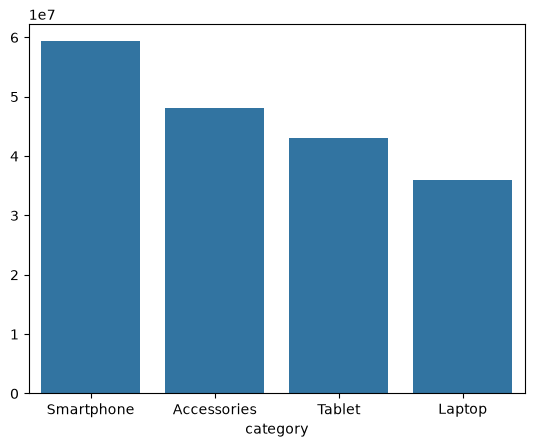

In [145]:
#Top category by revenue
sns.barplot(x=Top_category.index, 
        y=Top_category.values)

<BarContainer object of 10 artists>

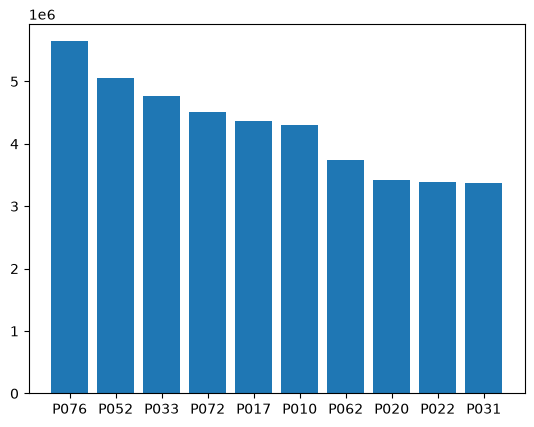

In [146]:
#TOP PRODUCTS BY REVENUE
plt.bar(top_product_revenue.index
         ,top_product_revenue.values)

<BarContainer object of 10 artists>

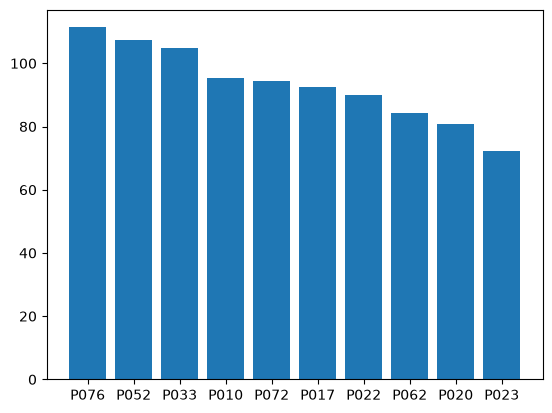

In [147]:
#Top products by Qty
plt.bar(top_product_qty.index,
        top_product_qty.values)

Text(0, 0.5, 'Revenue')

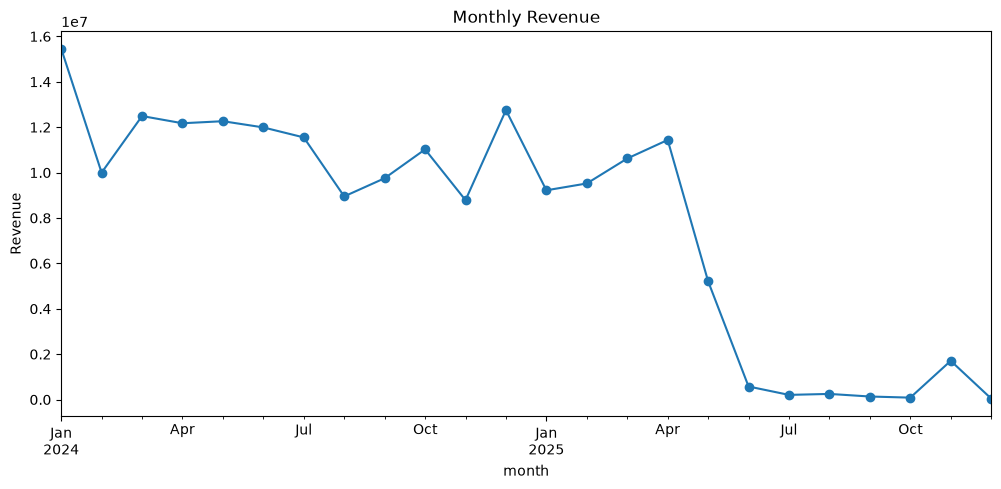

In [169]:
#Monthly sales
monthly_sales.plot(figsize=(12,5),marker='o')
plt.title("Monthly Revenue")
plt.ylabel("Revenue")

<Axes: xlabel='customer_id'>

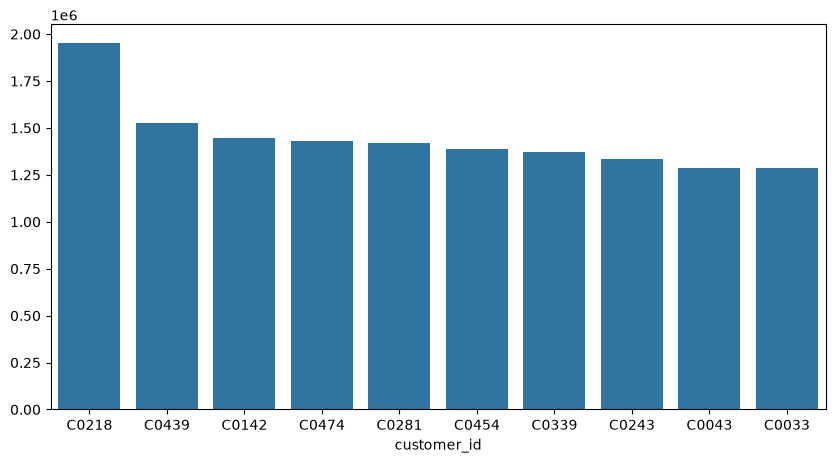

In [189]:
#Top customers by revenue
plt.figure(figsize=(10,5))
sns.barplot(x=top_customer_revenue.index,
    y=top_customer_revenue.values)

<BarContainer object of 10 artists>

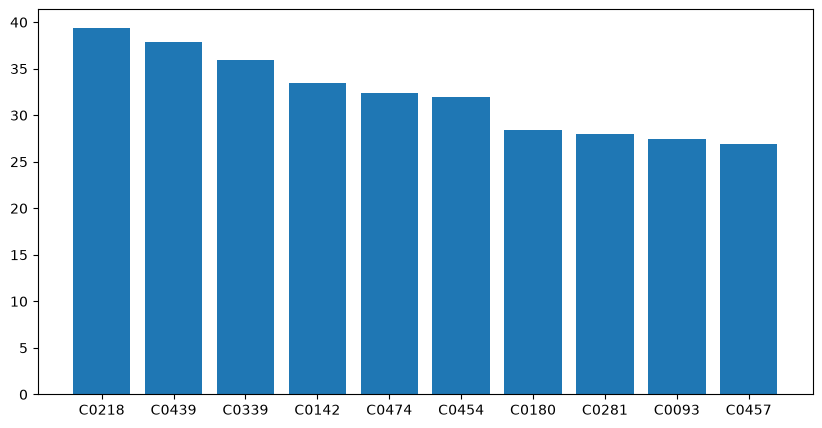

In [179]:
#Top customers by Qty
plt.figure(figsize=(10,5))
plt.bar(top_customers_qty.index,
        top_customers_qty.values)

Text(0, 0.5, 'Payment method')

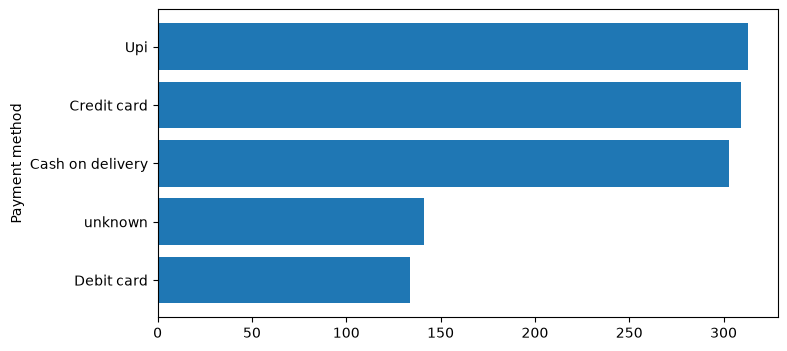

In [187]:
#TOP PAYMENT METHOD
payment = order.groupby("payment_method")["order_id"].count().sort_values(ascending=True)
plt.figure(figsize=(8,4))
plt.barh(payment.index,
      payment.values )
plt.ylabel("Payment method")

<Axes: xlabel='city'>

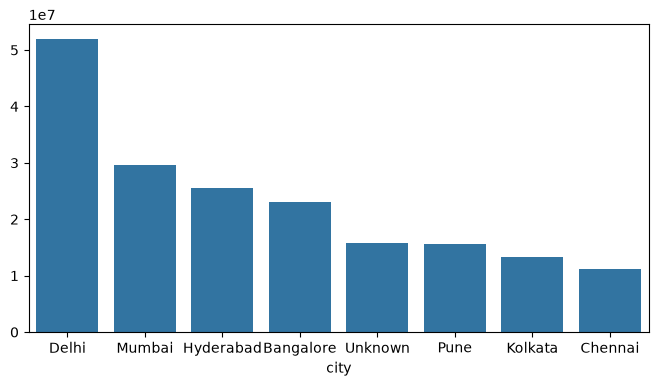

In [184]:
#top cities by revenue
city_wise_distrobution= customer.merge(order,on='customer_id').merge(order_details,on='order_id')
top_city=city_wise_distrobution.groupby('city')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=top_city.index, 
        y=top_city.values)

<Axes: xlabel='category'>

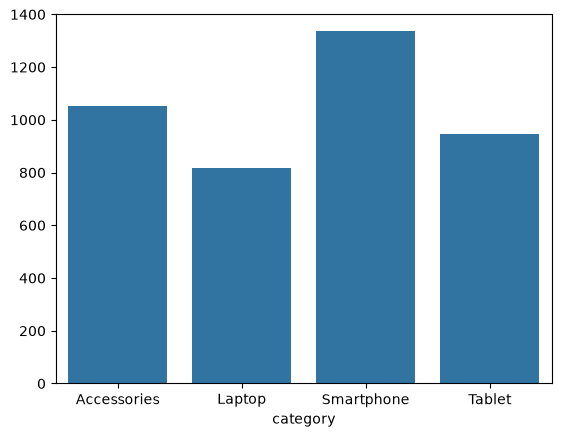

In [155]:
#Quantity Sold by Category
table=order_details.merge(product,on='product_id',how='outer')
quantity_sold_by_category=table.groupby('category')['quantity'].sum().round()

sns.barplot(x=quantity_sold_by_category.index,
           y=quantity_sold_by_category.values)